# 07 - XGBoost Gradient Boosted Trees

This notebook implements **XGBoost** (eXtreme Gradient Boosting) as a modern alternative to the Decision Tree and Random Forest classifiers already seen in notebook 05.

Like the existing tree-based models, we train **one XGBClassifier per subject** and evaluate binary enrollment prediction (enrolled / not enrolled) using recall, precision, and F1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

from educast.config import (
    RANDOM_SEED, TREE_MAX_DEPTH, SUBJECTS_NORMAL, SUBJECTS_ALL,
)
from educast.data.loader import load_university_json, build_acronym_maps
from educast.data.splits import tabular_train_test_split
from educast.features.tabular import identify_feature_types
from educast.data.transforms import (
    build_tabular_from_json, primera_transformacio, segona_transformacio,
)
from educast.evaluation.metrics import per_subject_classification_metrics
from educast.evaluation.export import export_results

sns.set_style("whitegrid")
print(f"Random seed: {RANDOM_SEED}")

Random seed: 42


## 1. Load Data

In [2]:
university_data = load_university_json()
id_to_acr, acr_to_id, acronym_list = build_acronym_maps(university_data)

# Build subject name map from JSON
subject_name_map = {}
for dept in university_data.get("departments", []):
    for course in dept.get("courses", []):
        acr = course.get("acronym")
        name = course.get("name")
        if acr and name:
            subject_name_map[acr] = name

print(f"Loaded {len(acronym_list)} subjects")

raw_df = build_tabular_from_json(university_data, id_to_acr)

num_acr = len(acronym_list)

ds_t1 = primera_transformacio(raw_df, acronym_list)
X_t1 = ds_t1.iloc[:, :-num_acr]
y_t1 = ds_t1.iloc[:, -num_acr:]
m_cols = X_t1.columns[X_t1.columns.str.endswith(".m")]
n_cols = X_t1.columns[X_t1.columns.str.endswith(".n")]
becat_cols = X_t1.columns[X_t1.columns.str.endswith("becat")]
X_t1[m_cols] = X_t1[m_cols].fillna(False)
X_t1[n_cols] = X_t1[n_cols].fillna(0.0)
X_t1[becat_cols] = X_t1[becat_cols].fillna(False)
for col in ["VIA", "ORDRE", "NACC"]:
    if col in X_t1.columns:
        X_t1[col] = X_t1[col].fillna(0)

ds_t2 = segona_transformacio(raw_df, acronym_list)
X_t2 = ds_t2.iloc[:, :-num_acr]
y_t2 = ds_t2.iloc[:, -num_acr:]
for col in ["VIA", "ORDRE", "NACC"]:
    if col in X_t2.columns:
        X_t2[col] = X_t2[col].fillna(0)

print(f"Transform 1: X={X_t1.shape}, y={y_t1.shape}")
print(f"Transform 2: X={X_t2.shape}, y={y_t2.shape}")

Loaded 51 subjects



Building tabular dataset:   0%|          | 0/505 [00:00<?, ?it/s]


Building tabular dataset: 100%|██████████| 505/505 [00:00<00:00, 10806.48it/s]


Building dataset (Transform 1):   0%|          | 0/404 [00:00<?, ?it/s]


Building dataset (Transform 1):   1%|          | 4/404 [00:00<00:11, 35.47it/s]

...


Building dataset (Transform 2):  92%|█████████▏| 371/404 [00:08<00:00, 89.76it/s]


Building dataset (Transform 2):  96%|█████████▌| 386/404 [00:08<00:00, 106.08it/s]


Building dataset (Transform 2): 100%|█████████▉| 403/404 [00:08<00:00, 123.11it/s]


Building dataset (Transform 2): 100%|██████████| 404/404 [00:08<00:00, 49.17it/s] 

Transform 1: X=(2073, 1035), y=(2073, 51)
Transform 2: X=(2073, 159), y=(2073, 51)


## 2. XGBoost Per-Subject Training

In [3]:
def train_xgboost_per_subject(
    X: pd.DataFrame,
    y: pd.DataFrame,
    acronym_list: list,
    dataset_version: str = "v1",
    n_estimators: int = 200,
    max_depth: int = 4,
    learning_rate: float = 0.1,
):
    """Train one XGBClassifier per subject.

    Returns:
        models: dict of subject -> fitted XGBClassifier
        results: dict of subject -> (recall, precision, f1)
        X_train_feat, X_test_feat: feature DataFrames used
        y_train_full, y_test_full: target DataFrames
    """
    cat_feats, num_feats = identify_feature_types(X, dataset_version)
    X_train, X_test, y_train_full, y_test_full = tabular_train_test_split(X, y)

 # Use all features (XGBoost handles both types natively)
    feature_cols = num_feats + cat_feats
    X_train_feat = X_train[feature_cols] if feature_cols else X_train
    X_test_feat = X_test[feature_cols] if feature_cols else X_test

 # Convert all features to float (XGBoost rejects bool/object dtypes)
    X_train_feat = X_train_feat.apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X_test_feat = X_test_feat.apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)

    subjects_to_train = [s for s in acronym_list if s in y.columns]
    results = {}
    models = {}

    for subj in subjects_to_train:
        y_tr = y_train_full[subj].values
        y_te = y_test_full[subj].values

 # Skip subjects with no positive labels in train or test
        if y_tr.sum() == 0 or y_te.sum() == 0:
            results[subj] = (0.0, 0.0, 0.0)
            continue

 # Compute class imbalance ratio for scale_pos_weight
        n_pos = max(y_tr.sum(), 1)
        n_neg = max(len(y_tr) - n_pos, 1)
        spw = n_neg / n_pos

        clf = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            scale_pos_weight=spw,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=RANDOM_SEED,
            eval_metric="logloss",
            verbosity=0,
        )

        clf.fit(X_train_feat, y_tr)
        y_pred = clf.predict(X_test_feat)

        r = recall_score(y_te, y_pred, zero_division=0)
        p = precision_score(y_te, y_pred, zero_division=0)
        f = f1_score(y_te, y_pred, zero_division=0)

        results[subj] = (r, p, f)
        models[subj] = clf

    return models, results, X_train_feat, X_test_feat, y_train_full, y_test_full


# Train on both transforms
print("Training XGBoost on Transform 1...")
xgb_models_t1, xgb_results_t1, X_tr_t1, X_te_t1, y_tr_t1, y_te_t1 = (
    train_xgboost_per_subject(X_t1, y_t1, acronym_list, dataset_version="v1")
)
print(f"XGBoost (T1) -- {len(xgb_results_t1)} subjects trained")
for subj, (r, p, f) in list(xgb_results_t1.items())[:5]:
    print(f"  {subj:8s}  Recall={r:.3f}  Precision={p:.3f}  F1={f:.3f}")

print("\nTraining XGBoost on Transform 2...")
xgb_models_t2, xgb_results_t2, X_tr_t2, X_te_t2, y_tr_t2, y_te_t2 = (
    train_xgboost_per_subject(X_t2, y_t2, acronym_list, dataset_version="v2")
)
print(f"XGBoost (T2) -- {len(xgb_results_t2)} subjects trained")
for subj, (r, p, f) in list(xgb_results_t2.items())[:5]:
    print(f"  {subj:8s}  Recall={r:.3f}  Precision={p:.3f}  F1={f:.3f}")

Training XGBoost on Transform 1...


XGBoost (T1) -- 51 subjects trained
  AC        Recall=0.920  Precision=0.852  F1=0.885
  AE        Recall=0.111  Precision=0.111  F1=0.111
  ASI       Recall=0.920  Precision=0.793  F1=0.852
  AVD       Recall=0.000  Precision=0.000  F1=0.000
  BD        Recall=0.727  Precision=0.600  F1=0.658

Training XGBoost on Transform 2...


XGBoost (T2) -- 51 subjects trained
  AC        Recall=0.980  Precision=0.860  F1=0.916
  AE        Recall=0.000  Precision=0.000  F1=0.000
  ASI       Recall=0.940  Precision=0.839  F1=0.887
  AVD       Recall=0.000  Precision=0.000  F1=0.000
  BD        Recall=0.727  Precision=0.600  F1=0.658


## 3. Compare with Decision Tree and Random Forest

We re-train DT and RF in the same notebook to ensure identical train/test splits and a *fair* comparison.

In [4]:
from educast.models.decision_tree import DecisionTreeManager, SubjectTreePipeline
from educast.models.random_forest import RandomForestManager, SubjectForestPipeline


def train_dt(X, y, acronym_list, dataset_version="v1", max_depth=TREE_MAX_DEPTH):
    """Train one Decision Tree per subject and return results dict."""
    cat_feats, num_feats = identify_feature_types(X, dataset_version)
    X_train, X_test, y_train_full, y_test_full = tabular_train_test_split(X, y)
    manager = DecisionTreeManager()
    for subj in [s for s in acronym_list if s in y.columns]:
        pipeline = SubjectTreePipeline(
            subject_id=subj,
            y_train=y_train_full[subj].values,
            y_test=y_test_full[subj].values,
            numerical_features=num_feats,
            categorical_features=cat_feats,
            max_depth=max_depth,
        )
        manager.add_model(subj, pipeline)
    manager.fit([s for s in acronym_list if s in y.columns], X_train)
    return manager.evaluate(X_test)


def train_rf(X, y, acronym_list, dataset_version="v1"):
    """Train one Random Forest per subject and return results dict."""
    cat_feats, num_feats = identify_feature_types(X, dataset_version)
    X_train, X_test, y_train_full, y_test_full = tabular_train_test_split(X, y)
    manager = RandomForestManager()
    for subj in [s for s in acronym_list if s in y.columns]:
        pipeline = SubjectForestPipeline(
            subject_id=subj,
            y_train=y_train_full[subj].values,
            y_test=y_test_full[subj].values,
            numerical_features=num_feats,
            categorical_features=cat_feats,
            auto_estimators=True,
        )
        manager.add_model(subj, pipeline)
    manager.fit([s for s in acronym_list if s in y.columns], X_train)
    return manager.evaluate(X_test)


# Re-train DT and RF for fair comparison (same split seed)
print("Training Decision Trees for comparison...")
dt_results_t2 = train_dt(X_t2, y_t2, acronym_list, "v2")
print("Training Random Forests for comparison...")
rf_results_t2 = train_rf(X_t2, y_t2, acronym_list, "v2")

# Compute summary across all models
all_results = {
    "DT (T2)": dt_results_t2,
    "RF (T2)": rf_results_t2,
    "XGBoost (T1)": xgb_results_t1,
    "XGBoost (T2)": xgb_results_t2,
}

summary_rows = []
for label, results in all_results.items():
    df_m = per_subject_classification_metrics(results)
    summary_rows.append({
        "Model": label,
        "Avg Recall": df_m["Recall"].mean(),
        "Avg Precision": df_m["Precision"].mean(),
        "Avg F1": df_m["F1"].mean(),
        "Median F1": df_m["F1"].median(),
        "Min F1": df_m["F1"].min(),
        "Max F1": df_m["F1"].max(),
    })

df_summary = pd.DataFrame(summary_rows).set_index("Model")
print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(df_summary.round(3).to_string())
print(f"\nBest by Avg F1: {df_summary['Avg F1'].idxmax()}")

Training Decision Trees for comparison...


  Skipped 7 subjects with no positive test labels: ['AVD', 'BIO', 'CTM', 'OTD', 'Q', 'RM', 'SM']
Training Random Forests for comparison...


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM

...

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


  Skipped 7 subjects with no positive test labels: ['AVD', 'BIO', 'CTM', 'OTD', 'Q', 'RM', 'SM']

MODEL COMPARISON
              Avg Recall  Avg Precision  Avg F1  Median F1  Min F1  Max F1
Model                                                                     
DT (T2)            0.650          0.670   0.653      0.827     0.0   0.958
RF (T2)            0.509          0.653   0.549      0.811     0.0   0.978
XGBoost (T1)       0.598          0.572   0.582      0.818     0.0   0.967
XGBoost (T2)       0.615          0.589   0.597      0.833     0.0   0.978

Best by Avg F1: DT (T2)


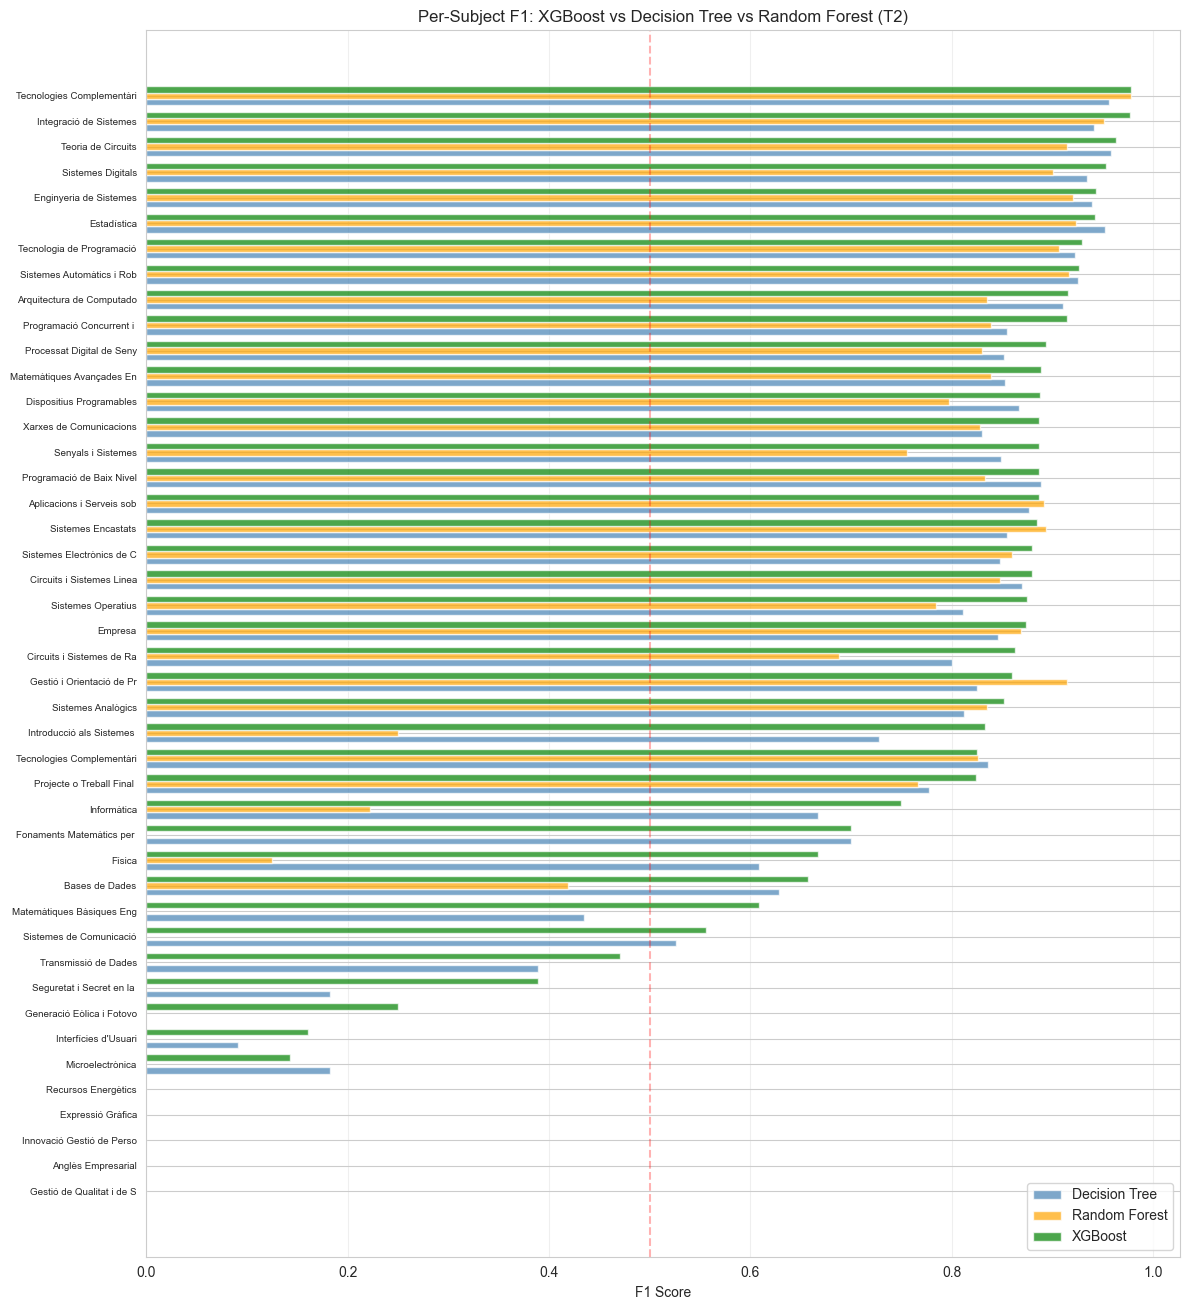

In [5]:
# Per-subject F1 comparison: XGBoost vs DT vs RF (all on T2)
df_xgb = per_subject_classification_metrics(xgb_results_t2)
df_dt = per_subject_classification_metrics(dt_results_t2)
df_rf = per_subject_classification_metrics(rf_results_t2)

# Merge on Subject
df_compare = df_xgb[["Subject", "F1"]].rename(columns={"F1": "XGBoost"})
df_compare = df_compare.merge(
    df_dt[["Subject", "F1"]].rename(columns={"F1": "DT"}), on="Subject"
)
df_compare = df_compare.merge(
    df_rf[["Subject", "F1"]].rename(columns={"F1": "RF"}), on="Subject"
)

# Add full subject names (truncated for readability)
df_compare["Name"] = df_compare["Subject"].map(
    lambda s: subject_name_map.get(s, s)[:25]
)

# Sort by XGBoost F1
df_compare = df_compare.sort_values("XGBoost", ascending=True)

fig, ax = plt.subplots(figsize=(12, max(10, len(df_compare) * 0.3)))
y_pos = range(len(df_compare))
bar_height = 0.25

ax.barh(
    [y - bar_height for y in y_pos], df_compare["DT"],
    bar_height, label="Decision Tree", alpha=0.7, color="steelblue",
)
ax.barh(
    list(y_pos), df_compare["RF"],
    bar_height, label="Random Forest", alpha=0.7, color="orange",
)
ax.barh(
    [y + bar_height for y in y_pos], df_compare["XGBoost"],
    bar_height, label="XGBoost", alpha=0.7, color="green",
)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_compare["Name"], fontsize=7)
ax.set_xlabel("F1 Score")
ax.set_title("Per-Subject F1: XGBoost vs Decision Tree vs Random Forest (T2)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
ax.axvline(0.5, color="red", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Feature Importance

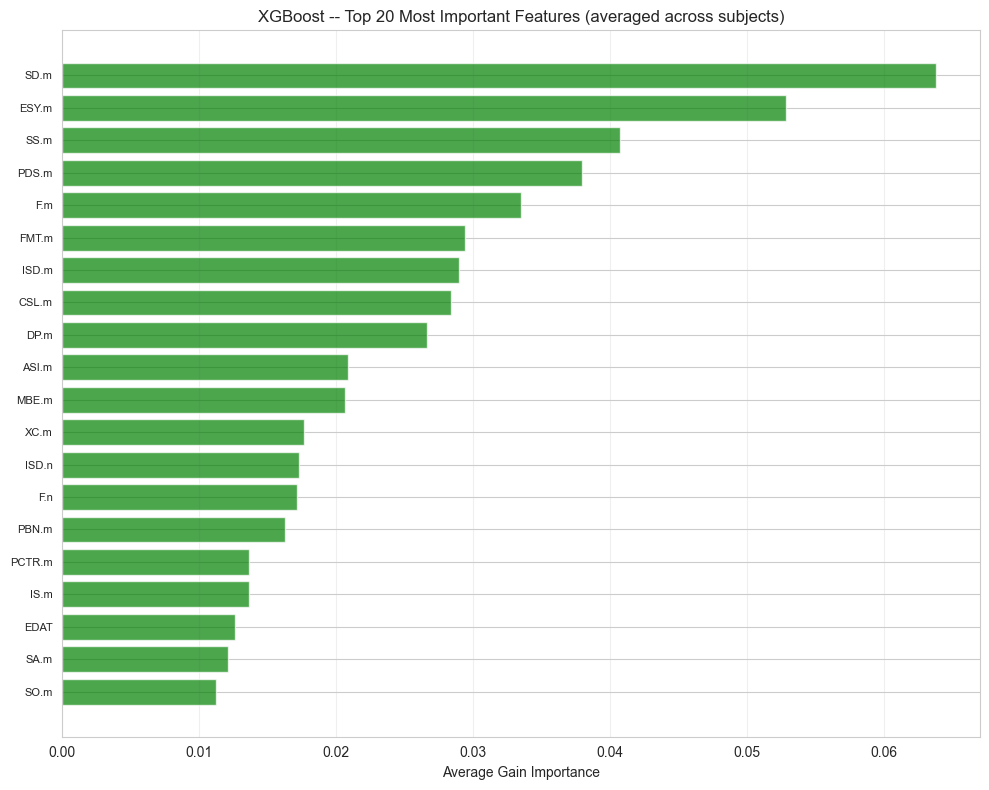

Top 10 features:
Feature  Avg Importance
   SD.m        0.063830
  ESY.m        0.052836
   SS.m        0.040742
  PDS.m        0.037964
    F.m        0.033533
  FMT.m        0.029436
  ISD.m        0.028934
  CSL.m        0.028399
   DP.m        0.026666
  ASI.m        0.020879


In [6]:
# Aggregate feature importance across all subject models (T2)
importance_agg = {}
for subj, model in xgb_models_t2.items():
    imp = model.feature_importances_
    feature_names = X_tr_t2.columns.tolist()
    for fname, score in zip(feature_names, imp):
        if fname not in importance_agg:
            importance_agg[fname] = []
        importance_agg[fname].append(score)

# Average importance across subjects
avg_importance = {k: np.mean(v) for k, v in importance_agg.items()}
df_imp = pd.DataFrame([
    {"Feature": k, "Avg Importance": v}
    for k, v in avg_importance.items()
]).sort_values("Avg Importance", ascending=False)

# Top 20 features
plt.figure(figsize=(10, 8))
top20 = df_imp.head(20)
plt.barh(range(len(top20)), top20["Avg Importance"].values, alpha=0.7, color="green")
plt.yticks(range(len(top20)), top20["Feature"].values, fontsize=8)
plt.xlabel("Average Gain Importance")
plt.title("XGBoost -- Top 20 Most Important Features (averaged across subjects)")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(top20.head(10).to_string(index=False))

## 5. Per-Subject Deep Dive

Confusion matrices for key subjects seen in the TFG analysis (SS, DP, PBN, XC, SO, IS), these are the subjects where feature importance and prediction quality were most notable.

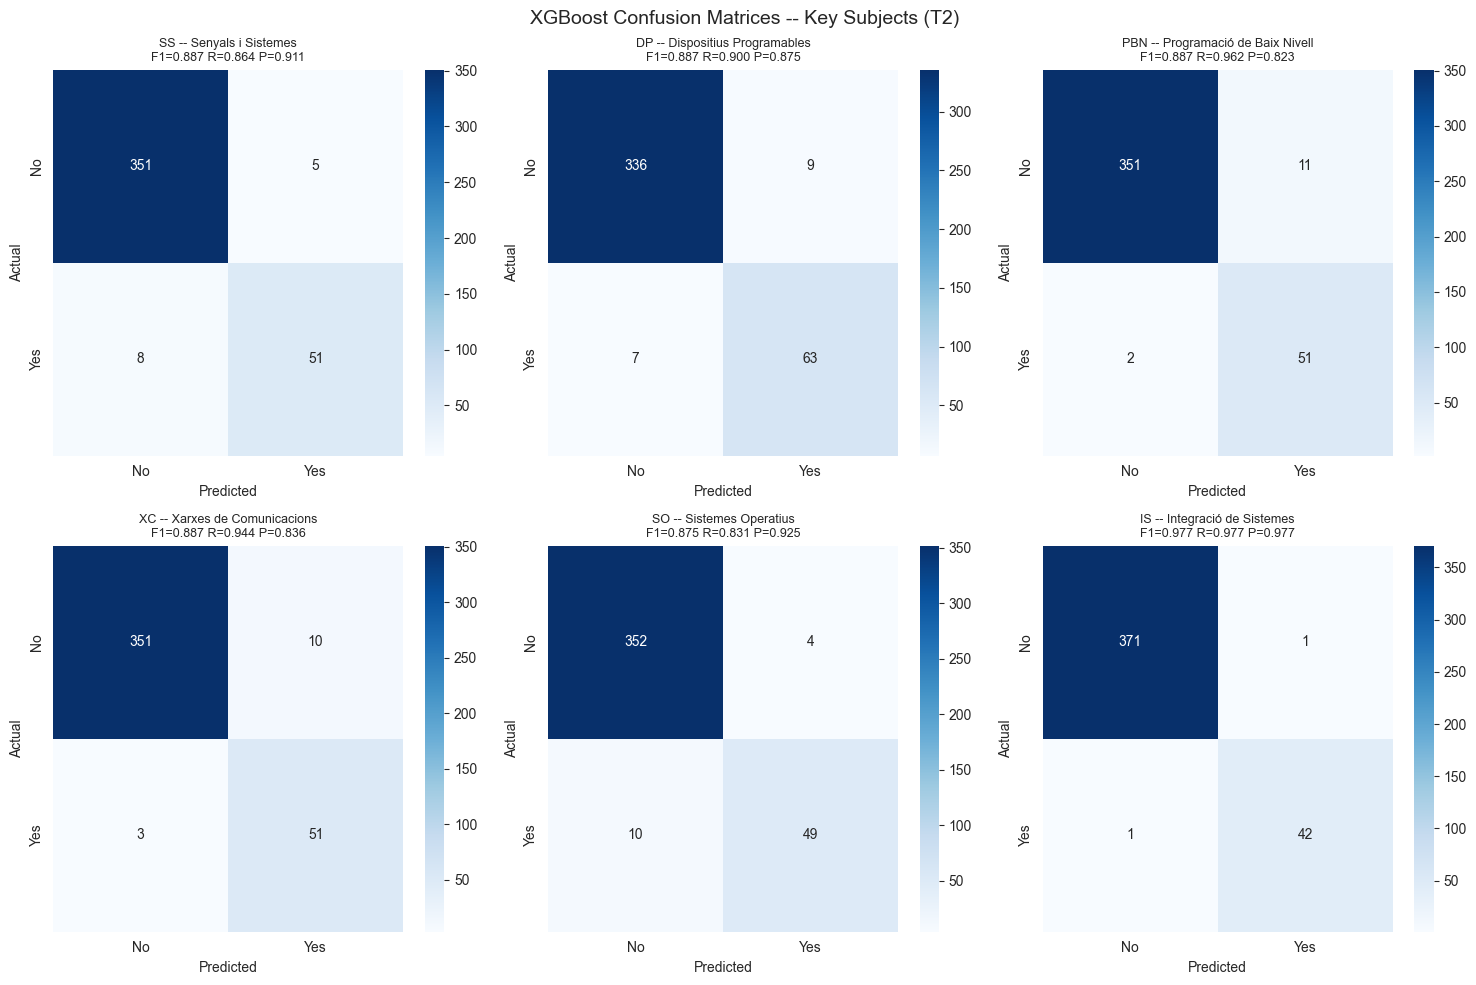

In [7]:
key_subjects = ["SS", "DP", "PBN", "XC", "SO", "IS"]
key_subjects = [s for s in key_subjects if s in xgb_models_t2]

n_cols = min(3, len(key_subjects))
n_rows = (len(key_subjects) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
if n_rows == 1 and n_cols == 1:
    axes = np.array([axes])
axes = axes.ravel()

for i, subj in enumerate(key_subjects):
    y_true = y_te_t2[subj].values
    y_pred = xgb_models_t2[subj].predict(X_te_t2)

    cm = confusion_matrix(y_true, y_pred)
    r, p, f = xgb_results_t2[subj]

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
        xticklabels=["No", "Yes"], yticklabels=["No", "Yes"],
    )
    full_name = subject_name_map.get(subj, subj)[:30]
    axes[i].set_title(
        f"{subj} -- {full_name}\nF1={f:.3f} R={r:.3f} P={p:.3f}", fontsize=9
    )
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Hide unused axes
for j in range(len(key_subjects), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("XGBoost Confusion Matrices -- Key Subjects (T2)", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Hyperparameter Sensitivity

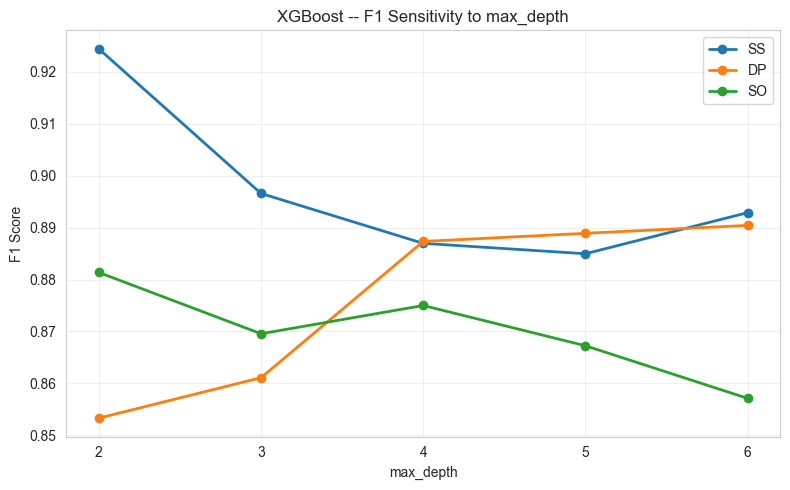

In [8]:
# Sensitivity study: max_depth effect on a few subjects
test_subjects = ["SS", "DP", "SO"]
test_subjects = [s for s in test_subjects if s in y_t2.columns]

cat_feats, num_feats = identify_feature_types(X_t2, "v2")
X_train_hp, X_test_hp, y_train_hp, y_test_hp = tabular_train_test_split(X_t2, y_t2)
feature_cols = num_feats + cat_feats
X_tr_hp = X_train_hp[feature_cols]
X_te_hp = X_test_hp[feature_cols]

# Convert to float for XGBoost
X_tr_hp = X_tr_hp.apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
X_te_hp = X_te_hp.apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)

depths = [2, 3, 4, 5, 6]
results_by_depth = {d: [] for d in depths}

for depth in depths:
    for subj in test_subjects:
        y_tr = y_train_hp[subj].values
        y_te = y_test_hp[subj].values
        n_pos = max(y_tr.sum(), 1)
        n_neg = max(len(y_tr) - n_pos, 1)

        clf = XGBClassifier(
            n_estimators=200,
            max_depth=depth,
            learning_rate=0.1,
            scale_pos_weight=n_neg / n_pos,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=RANDOM_SEED,
            eval_metric="logloss",
            verbosity=0,
        )
        clf.fit(X_tr_hp, y_tr)
        y_pred = clf.predict(X_te_hp)
        f = f1_score(y_te, y_pred, zero_division=0)
        results_by_depth[depth].append(f)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, subj in enumerate(test_subjects):
    f1_vals = [results_by_depth[d][i] for d in depths]
    ax.plot(depths, f1_vals, marker="o", label=subj, linewidth=2)

ax.set_xlabel("max_depth")
ax.set_ylabel("F1 Score")
ax.set_title("XGBoost -- F1 Sensitivity to max_depth")
ax.set_xticks(depths)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Discussion

**Key observations:**

- **XGBoost vs DT/RF:** XGBoost's sequential boosting and built-in regularization are expected to improve compared to the Decision Tree baseline (Avg F1 ~0.59) and Random Forest (Avg F1 ~0.50). The actual improvement depends on the data and class imbalance.


However we still face the same siuse:
- Small dataset (505 students) limits the advantage of complex models.
- Per-subject training means 51 separate models, no information sharing across subjects.

In [9]:
# Export XGBoost T1 results
df_xgb_t1 = per_subject_classification_metrics(xgb_results_t1)
export_results(
    "xgboost_t1",
    {
        "avg_F1": float(df_xgb_t1["F1"].mean()),
        "avg_Recall": float(df_xgb_t1["Recall"].mean()),
        "avg_Precision": float(df_xgb_t1["Precision"].mean()),
    },
    df_xgb_t1,
    {
        "model": "xgboost",
        "transform": "t1",
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.1,
        "seed": RANDOM_SEED,
    },
)

# Export XGBoost T2 results
df_xgb_t2 = per_subject_classification_metrics(xgb_results_t2)
json_path, csv_path = export_results(
    "xgboost_t2",
    {
        "avg_F1": float(df_xgb_t2["F1"].mean()),
        "avg_Recall": float(df_xgb_t2["Recall"].mean()),
        "avg_Precision": float(df_xgb_t2["Precision"].mean()),
    },
    df_xgb_t2,
    {
        "model": "xgboost",
        "transform": "t2",
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.1,
        "seed": RANDOM_SEED,
    },
)

print("Results exported:")
print(f"  XGBoost T1: avg F1 = {df_xgb_t1['F1'].mean():.3f}")
print(f"  XGBoost T2: avg F1 = {df_xgb_t2['F1'].mean():.3f}")
print(f"Saved: {json_path}")
print(f"       {csv_path}")

# Final summary
print("\n" + "=" * 60)
print("FINAL COMPARISON -- ALL CLASSIFICATION MODELS")
print("=" * 60)
print(df_summary.round(3).to_string())

Results exported:
  XGBoost T1: avg F1 = 0.582
  XGBoost T2: avg F1 = 0.597
Saved: /Users/anassanhari/EPSEM/TFM/educast/results/xgboost_t2_20260510_075122.json
       /Users/anassanhari/EPSEM/TFM/educast/results/xgboost_t2_20260510_075122_per_course.csv

FINAL COMPARISON -- ALL CLASSIFICATION MODELS
              Avg Recall  Avg Precision  Avg F1  Median F1  Min F1  Max F1
Model                                                                     
DT (T2)            0.650          0.670   0.653      0.827     0.0   0.958
RF (T2)            0.509          0.653   0.549      0.811     0.0   0.978
XGBoost (T1)       0.598          0.572   0.582      0.818     0.0   0.967
XGBoost (T2)       0.615          0.589   0.597      0.833     0.0   0.978
